<a href="https://colab.research.google.com/github/marioarsw/AnaliticaDescriptiva/blob/main/practicas/practica7_267370.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Maestría en Inteligencia Artificial y Analítica de Datos


*   Curso: Programación para Analítica Descriptiva y Predictiva
*   Semestre: Enero-Junio
*   Profesor: Dr. Vicente García Jiménez



## Práctica 7: Análisis de un Dataset con Matplotlib

## Mario Amador - 267370.

El objetivo de este ejercicio es que los estudiantes aprendan a cargar y explorar un dataset, y luego utilicen matplotlib para crear gráficos visuales que les permitan analizar e interpretar los datos.

Dataset:
Para este ejercicio, utilizaremos el famoso dataset Iris de la librería seaborn. Este dataset contiene información sobre diferentes especies de flores Iris y varias medidas de sus características (como el largo y ancho del sépalo y el pétalo).

Los estudiantes pueden cargarlo directamente desde la librería seaborn. Para ello emplea la siguiente instrucción:
```python
df = sns.load_dataset('iris')
```

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Carga y exploración del dataset:

* Cargar el dataset Iris utilizando seaborn o cualquier otro dataset de su elección.
* Verificar las primeras filas del dataset con el método .head().
* Obtener información general sobre los datos (nombres de columnas, tipos de datos, valores nulos, etc.).

In [2]:
iris = sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
iris.shape
# 150 registros, 5 columnas

(150, 5)

In [7]:
iris.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [9]:
iris.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [11]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [12]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [15]:
# Ver especies disponibles
# iris['species'].unique()
iris['species'].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


### ¿De qué trata el dataset?
* Habla sobre el tipo de flor iris y sus 3 variantes, setosa, versicolor y virginica.
* Tiene 4 columnas que describen el largo (length) y ancho (width) de las flores iris con respecto al pétalo y sépalo:

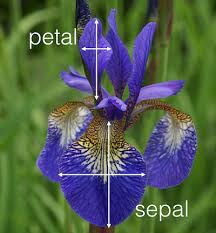

* Así se ve la diferencia entre los diferentes tipos de iris:

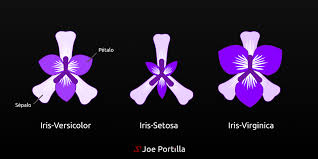

Donde:

Setosa -> pétalos pequeños

Versicolor -> pétalos medianos

Virginica -> pétalos grandes



# Gráfico de barras

* Objetivo: Comparar el promedio de largo y ancho de los pétalos entre las tres especies de Iris.
* Instrucciones: Utiliza un gráfico de barras para mostrar la media de las columnas petal_length y petal_width agrupadas por species.


Agrupar por especies y luego sacar el promedio

In [27]:
# Agrupar por especie para sacaer el promedio del petal en length y width
petal_means = iris.groupby('species')[['petal_length', 'petal_width']].mean()

# Convertirlo en df para poder leerlo después
petal_means = petal_means.reset_index()
petal_means

,species,petal_length,petal_width
0,setosa,1.462,0.246
1,versicolor,4.260,1.326
2,virginica,5.552,2.026


In [ ]:
species = petal_means['species']
x = np.arange(len(species))  # arange crea la distribución equitativa -> [0, 1, 2]
width = 0.35                 # ancho de cada barra

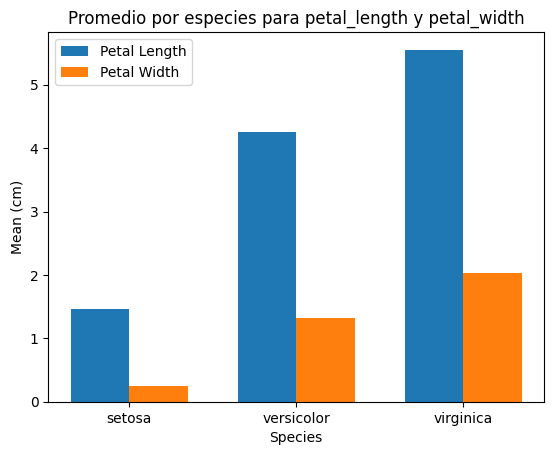

In [37]:
plt.figure()

# Barra para petal_length
plt.bar(
    x - width/2, # -> Para centrar los títulos
    petal_means['petal_length'],
    width,
    label='Petal Length'
)

# Barra para petal_width
plt.bar(
    x + width/2,
    petal_means['petal_width'],
    width,
    label='Petal Width'
)

# Etiquetas
plt.xlabel('Species')
plt.ylabel('Mean (cm)')
plt.title('Promedio por especies para petal_length y petal_width')
plt.xticks(x, species)
plt.legend()

plt.show()


# Histograma

* Objetivo: Visualizar la distribución de los largos de los sépalos (sepal_length).
* Instrucciones: Crea un histograma de la variable sepal_length y asegúrate de que tenga un número adecuado de bins. Coloca etiquetas en los ejes y un título.

### Notas:
* El histograma **no compara categorías**
* Muestra frecuencia de valores
* Sirve para ver
    1. Concentración
    2. Dispersión
    3. Posible sesgo

* Bins: Son los intervalos
* Pocos bins: Se pierde detalle
* Muchos bins: Provoca ruido
* Cada barra contará los valores que caen en ese rango

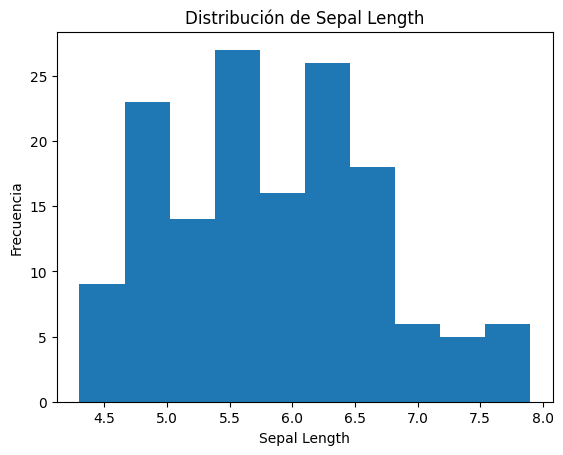

In [40]:
plt.hist(
    iris['sepal_length'],
    bins=10
)

plt.title('Distribución de Sepal Length')
plt.xlabel('Sepal Length')
plt.ylabel('Frecuencia')

plt.show()

# Gráfico de dispersión (scatter plot)

* Objetivo: Relacionar el largo del pétalo con el ancho del pétalo.
* Instrucciones: Crea un gráfico de dispersión que compare petal_length con petal_width. Usa un color diferente para cada especie.

### Notas:
Scatter plot sirve para relacionar dos vairables númericas:
En eje x una variable
En eje y otra variable
Respondeo a:
¿Cuándo x aumenta y también aumenta?
¿Hay valores atípicos (outliers)?

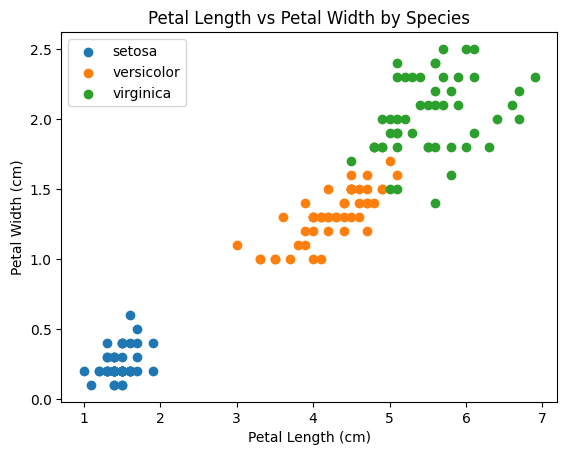

In [41]:
# Obtener especies únicas
species = iris['species'].unique() # Esto sería un hue de sns

plt.figure()

for sp in species:
    subset = iris[iris['species'] == sp]
    plt.scatter(
        subset['petal_length'],
        subset['petal_width'],
        label=sp
    )

plt.title('Petal Length vs Petal Width by Species')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend()

plt.show()

# Gráfico de cajas (box plot)

* Objetivo: Analizar la distribución de las medidas del sépalo (sepal_length, sepal_width).
* Instrucciones: Crea un gráfico de cajas para mostrar la distribución de las variables sepal_length y sepal_width por especie.


### Notas:
Un box plot, responde a la pregunta:
¿Dónde está la mayoría de mis datos y qué tan dispersos están?
Esto con respecto a la mediana
* No muestra cada dato como scatter
* Resume muchos números en una sola figura

La caja son los valores que están entre el cuartil 1 (Q1) y el cuartil 3 (Q3)

### Ejemplo para entender los diferentes conceptos

Teniendo los siguientes datos:

2, 4, 5, 7, 8, 10, 12, 14

La mediana es el valor del centro:

(7 + 8) / 2 = 7.5

### Cuartil 1 (Q1)
Q1 es el punto donde termina el 25% de los datos más pequeños:
La mitad inferior es:
2, 4, 5, 7
La mediana de eso es:
(4 + 5) / 2 = 4.5 = Q1

### Cuartil 3 (Q3)
Q3 es el punto donde termina el 75% de los datos
La mitad superior:
8, 10, 12, 14
La mediana:
(10 + 12) / 2 = 11 = Q3

### Rango intercuartílico (IQR)
Indica qué tan abiertos están los datos del centro
IQR = Q3 - Q1
IQR = 11 - 4.5 = 6.5

### Los bigotes
Muestran hasta dónde llegan los datos normales

### Los outliers
Son valores que están más allá de los bigotes

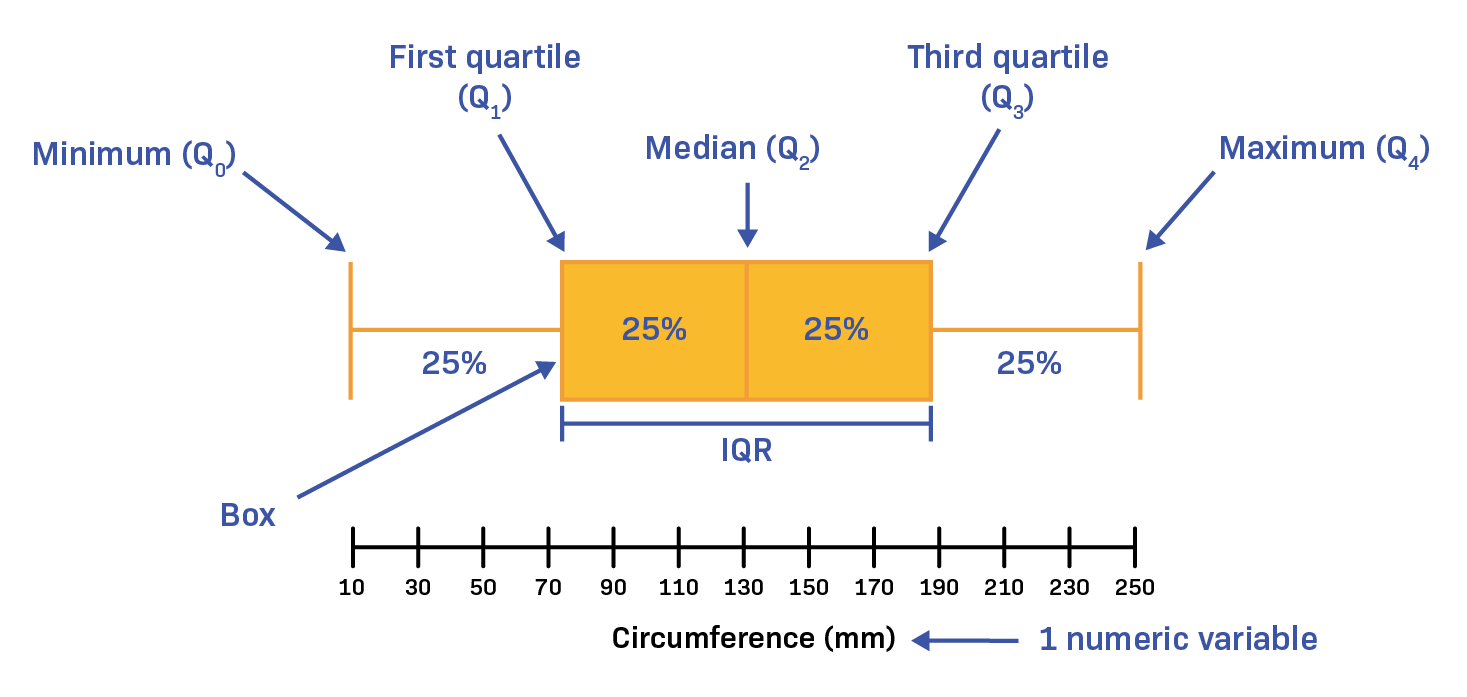



In [54]:
species = iris['species'].unique()

print(species)

sepal_length_data = [
    iris[iris['species'] == sp]['sepal_length']
    for sp in species
]

sepal_width_data = [
    iris[iris['species'] == sp]['sepal_width']
    for sp in species
]

# sepal_length_data[2]

# Lo anterior es lo mismo a:
# sepal_length_data = []

# for sp in species:
#     valores = iris[iris['species'] == sp]['sepal_length']
#     sepal_length_data.append(valores)


['setosa' 'versicolor' 'virginica']


/tmp/ipython-input-1038121875.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


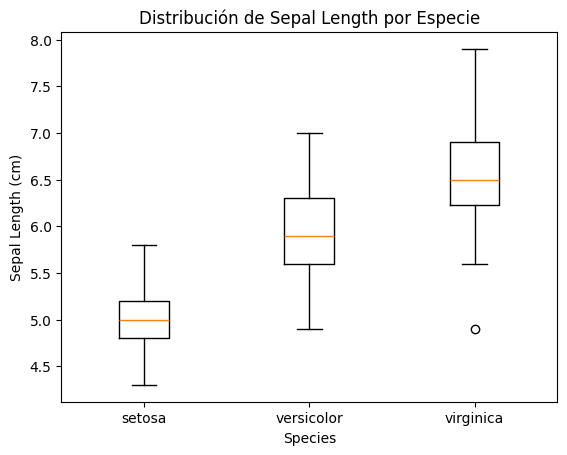

In [43]:
plt.figure()

plt.boxplot(
    sepal_length_data,
    labels=species
)

plt.title('Distribución de Sepal Length por Especie')
plt.xlabel('Species')
plt.ylabel('Sepal Length')

plt.show()

/tmp/ipython-input-1104604172.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


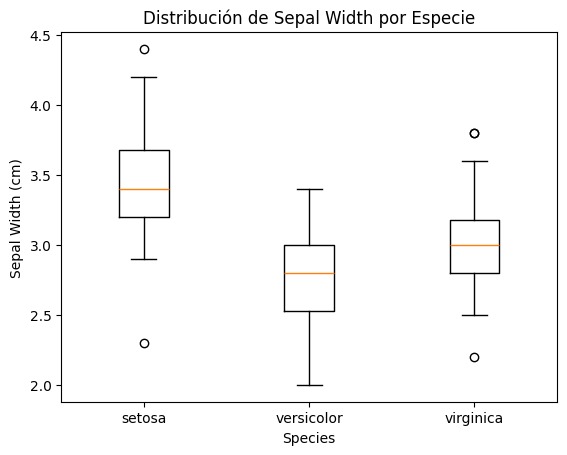

In [44]:
plt.figure()

plt.boxplot(
    sepal_width_data,
    labels=species
)

plt.title('Distribución de Sepal Width por Especie')
plt.xlabel('Species')
plt.ylabel('Sepal Width (cm)')

plt.show()

# Gráfico de líneas (Line plot)

* Objetivo: Mostrar la tendencia de la longitud del pétalo (petal_length) a través de las observaciones.
* Instrucciones: Crea un gráfico de líneas utilizando la variable petal_length (en el eje Y) con el índice de las observaciones (en el eje X). Puedes hacer esto para ver cómo varía la longitud del pétalo a lo largo del dataset.



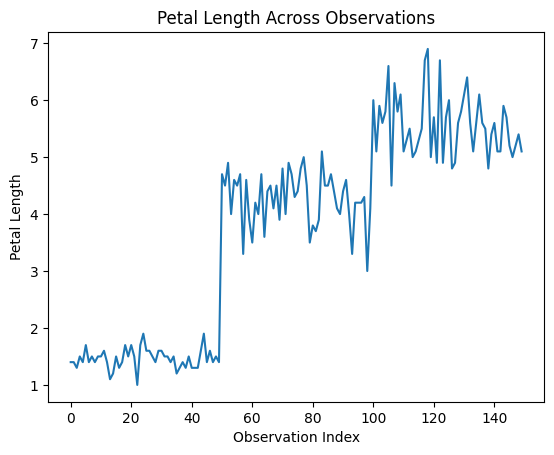

In [56]:
plt.figure()

plt.plot(
    iris.index,
    iris['petal_length']
)

plt.title('Petal Length Across Observations')
plt.xlabel('Observation Index')
plt.ylabel('Petal Length')

plt.show()